# Map Converter
This is a Jupyter Notebook to Convert a `.png` or `.pgm` + `.yaml` of a map into a `.csv` that can be fed into the TUMFTM functions.

High Level Steps:
1. Get the Euclidean Distance Transform of the map
2. Apply skeletonization to the map to extract centerlines
3. Run DFS to extract the centerline xy coordinates in order
4. Apply the transformations to go from pixel to meter coordinate frame


Map Conditions:
- Map edges should be well defined, inside should be white, walls are black and outside is grey

In [1]:
import numpy as np
from skimage.morphology import skeletonize
import matplotlib.pyplot as plt
import yaml
import scipy
from scipy.ndimage import distance_transform_edt as edt
from PIL import Image
import os

In [2]:
MAP_NAME = "my_map"

TRACK_WIDTH_MARGIN = 0.0 # Extra Safety margin, in meters

Image shape: (824, 763), dtype: float64, value range: [0.0, 255.0]


Text(0.5, 1.0, 'my_map — raw map')

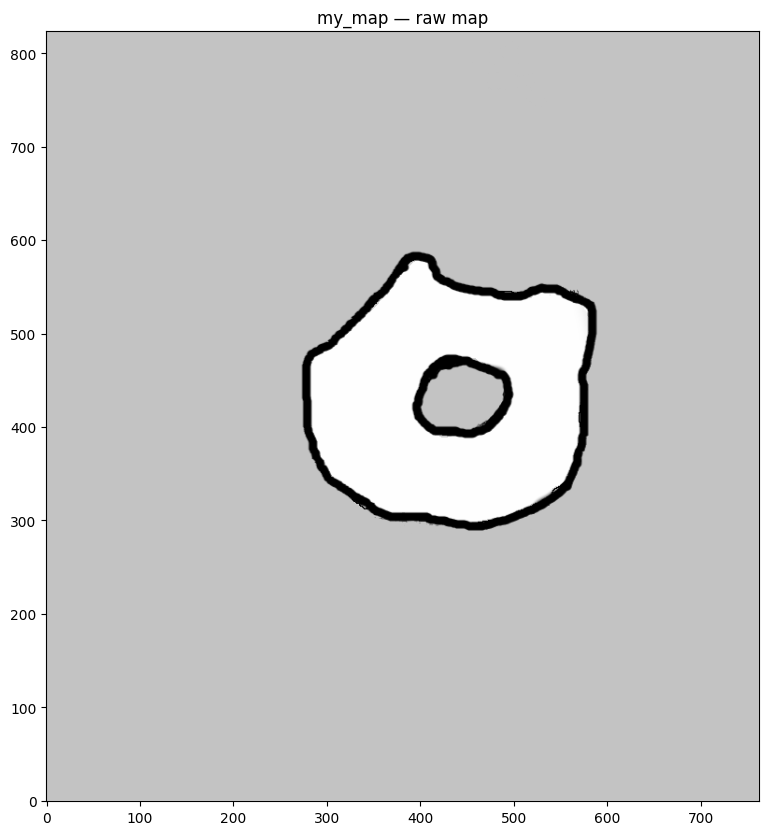

In [3]:
# # Modified from https://github.com/CL2-UWaterloo/Head-to-Head-Autonomous-Racing/blob/main/gym/f110_gym/envs/laser_models.py
# # load map image

# if os.path.exists(f"maps/{MAP_NAME}.png"):
#     map_img_path = f"maps/{MAP_NAME}.png"
# elif os.path.exists(f"maps/{MAP_NAME}.pgm"):
#     map_img_path = f"maps/{MAP_NAME}.pgm"
# else:
#     raise Exception("Map not found!")

# map_yaml_path = f"maps/{MAP_NAME}.yaml"
# raw_map_img = np.array(Image.open(map_img_path).transpose(Image.FLIP_TOP_BOTTOM))
# raw_map_img = raw_map_img.astype(np.float64)

# plt.figure(figsize=(10, 10))
# plt.imshow(raw_map_img, cmap='gray', origin='lower')



# Load map image
if os.path.exists(f"maps/{MAP_NAME}.png"):
    map_img_path = f"maps/{MAP_NAME}.png"
elif os.path.exists(f"maps/{MAP_NAME}.pgm"):
    map_img_path = f"maps/{MAP_NAME}.pgm"
else:
    raise Exception("Map not found!")

map_yaml_path = f"maps/{MAP_NAME}.yaml"

# Force convert to grayscale ('L' = 8-bit) to handle any PNG mode (RGBA, P, I, etc.)
pil_img = Image.open(map_img_path).convert('L').transpose(Image.FLIP_TOP_BOTTOM)
raw_map_img = np.array(pil_img).astype(np.float64)

print(f"Image shape: {raw_map_img.shape}, dtype: {raw_map_img.dtype}, value range: [{raw_map_img.min()}, {raw_map_img.max()}]")

plt.figure(figsize=(10, 10))
plt.imshow(raw_map_img / 255.0, cmap='gray', origin='lower')  # normalize to [0,1] for display
plt.title(f"{MAP_NAME} — raw map")


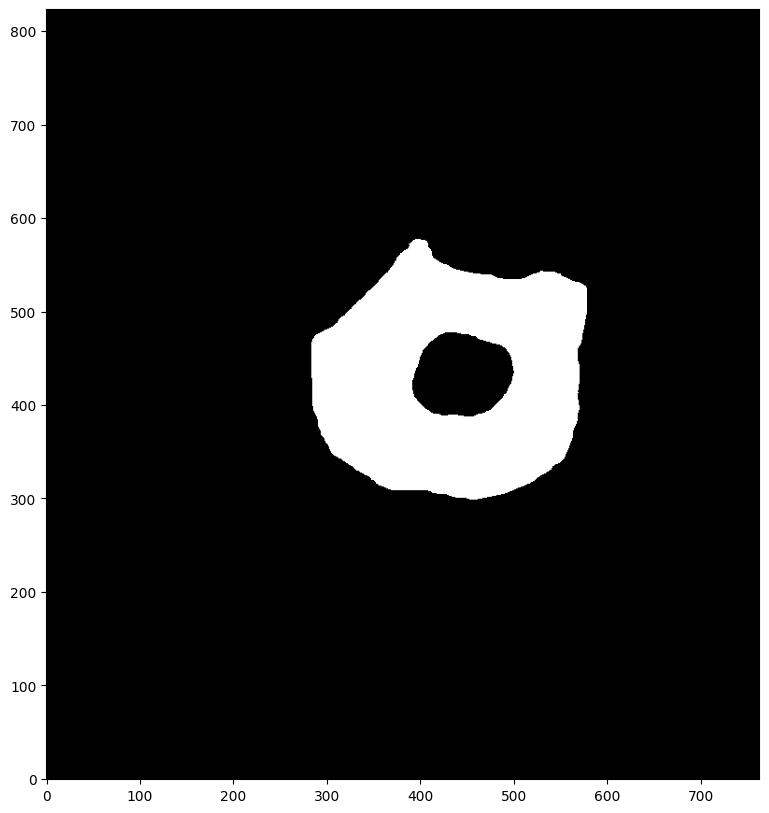

In [4]:
# grayscale -> binary. Converts grey to black
map_img = raw_map_img.copy()
map_img[map_img <= 210.] = 0
map_img[map_img > 210.] = 1

map_height = map_img.shape[0]
# map_width = map_img.shape[1]
map_img
plt.figure(figsize=(10, 10))
plt.imshow(map_img, cmap='gray', origin='lower')

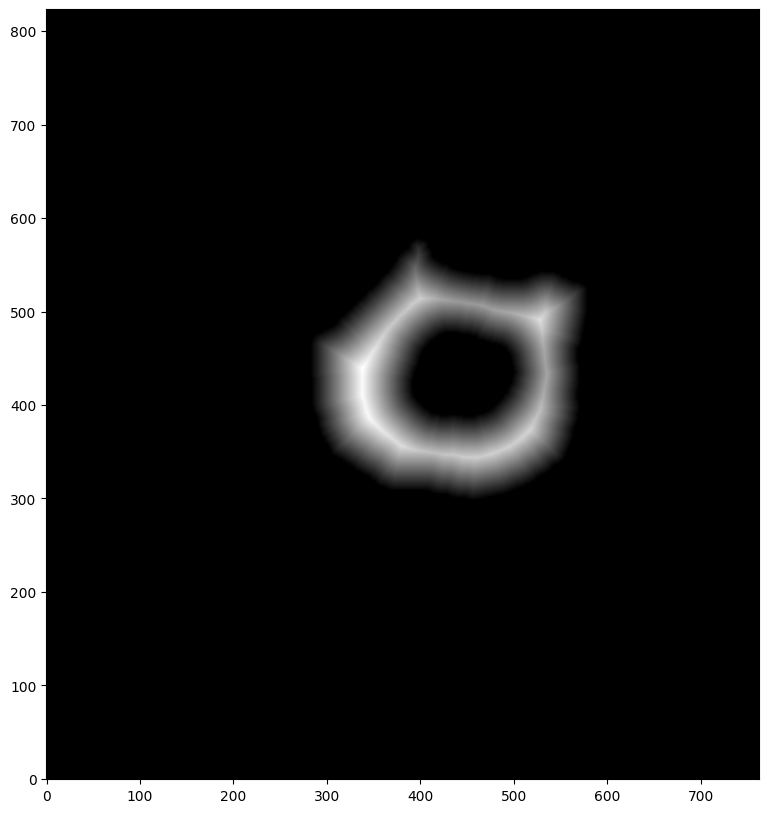

In [5]:
plt.figure(figsize=(10, 10))
# Calculate Euclidean Distance Transform (tells us distance to nearest wall)
dist_transform = scipy.ndimage.distance_transform_edt(map_img)
plt.imshow(dist_transform, cmap='gray', origin='lower')

THRESHOLD=0.17 → 42072 centerline candidate pixels (6.69% of map)


Text(0.5, 1.0, 'Thresholded at 0.17 x max | 42072 pixels')

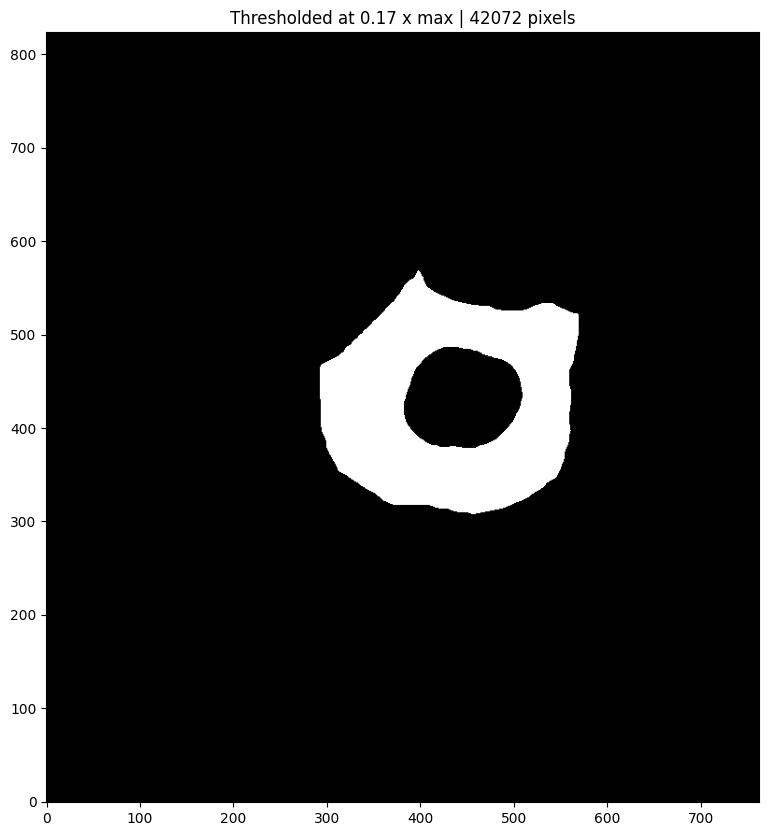

In [6]:
# Threshold the distance transform to create a binary image
# THRESHOLD: fraction of max distance value to keep as centerline candidates
#   Increase (e.g. 0.20–0.35) if you see hairy/branching lines
#   Decrease (e.g. 0.10–0.15) if no centerline appears
THRESHOLD = 0.17

centers = dist_transform > THRESHOLD * dist_transform.max()
n_pixels = int(centers.sum())
map_total = map_img.size

print(f"THRESHOLD={THRESHOLD} → {n_pixels} centerline candidate pixels ({100*n_pixels/map_total:.2f}% of map)")

if n_pixels == 0:
    raise ValueError(f"THRESHOLD={THRESHOLD} is too high — no centerline pixels found. Lower the value.")
if n_pixels > 0.25 * map_total:
    print(f"WARNING: {n_pixels} pixels is {100*n_pixels/map_total:.1f}% of map — THRESHOLD may be too low. Try increasing it.")

plt.figure(figsize=(10, 10))
plt.imshow(centers.astype(np.uint8), origin='lower', cmap='gray')

plt.title(f"Thresholded at {THRESHOLD} x max | {n_pixels} pixels")


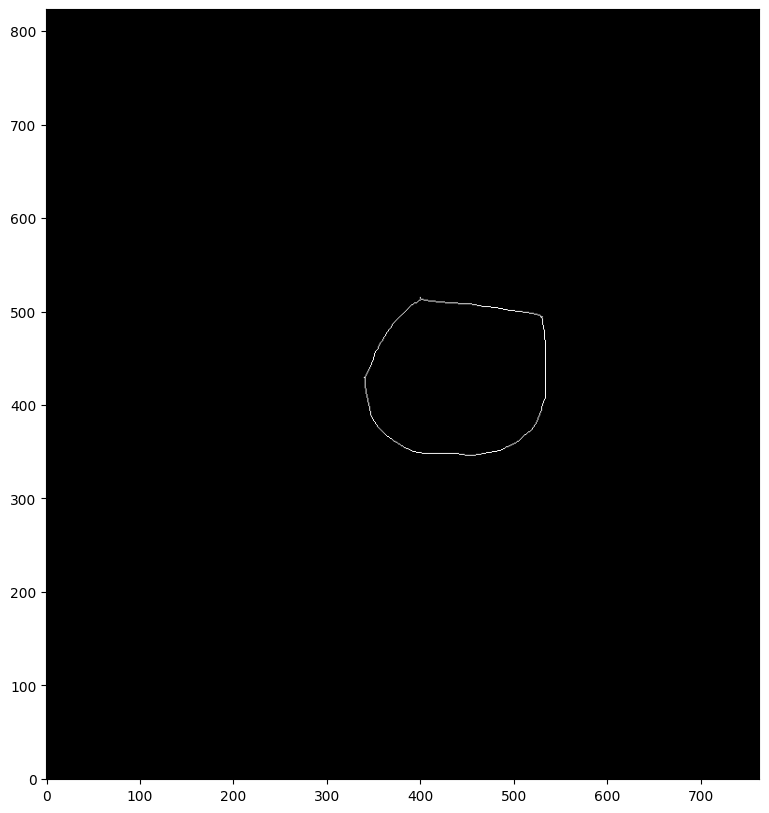

In [7]:
from scipy.ndimage import convolve as _nd_convolve
from scipy.ndimage import label

def prune_skeleton(skel, iterations=15):
    """Remove short spur branches from a binary skeleton."""
    kernel = np.ones((3, 3), dtype=np.uint8)
    result = skel.copy().astype(np.uint8)
    for _ in range(iterations):
        neighbor_count = _nd_convolve(result, kernel, mode='constant', cval=0) - result
        endpoints = (result == 1) & (neighbor_count == 1)
        if not endpoints.any():
            break
        result[endpoints] = 0
    return result.astype(bool)

def keep_largest_component(skel):
    """Keep only the largest connected component to remove noise."""
    structure = np.ones((3,3), dtype=int)
    labeled, ncomponents = label(skel, structure)
    if ncomponents == 0:
        return skel
    sizes = [np.sum(labeled == i) for i in range(1, ncomponents + 1)]
    largest_label = np.argmax(sizes) + 1
    return labeled == largest_label

plt.figure(figsize=(10, 10))
raw_skel = skeletonize(centers)
main_skel = keep_largest_component(raw_skel)
centerline = prune_skeleton(main_skel, iterations=50)
plt.imshow(centerline.astype(np.uint8), origin='lower', cmap='gray')

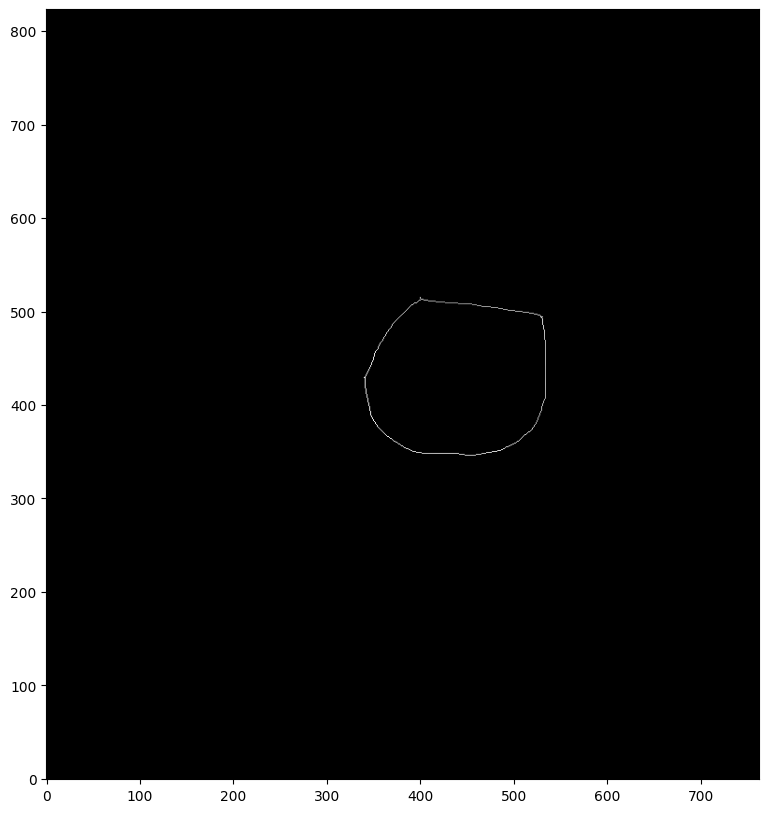

In [8]:
# The centerline has the track width encoded
plt.figure(figsize=(10, 10))
centerline_dist = np.where(centerline, dist_transform, 0)
plt.imshow(centerline_dist, origin='lower', cmap='gray')  # already float, this is fine


In [9]:
# Automatically find a robust starting point on the centerline.
# No hardcoded pixel offsets — works for any map size or resolution.

nonzero_ys, nonzero_xs = np.where(centerline_dist > 0)

if len(nonzero_ys) == 0:
    raise ValueError("No centerline found! Check THRESHOLD value or map image quality.")

h, w = centerline_dist.shape
mid_y = h // 2

# Prefer candidates within 10% of the vertical center (likely on a straight)
center_mask = np.abs(nonzero_ys - mid_y) < (h * 0.1)

if center_mask.sum() > 0:
    cand_ys = nonzero_ys[center_mask]
    cand_xs = nonzero_xs[center_mask]
    # Pick leftmost point for a consistent, repeatable DFS entry
    best = np.argmin(cand_xs)
    left_start_x = int(cand_xs[best])
    left_start_y = int(cand_ys[best])
    print(f"Start point selected from {center_mask.sum()} candidates near vertical center")
else:
    # Fallback: closest pixel to the vertical center of the image
    best = np.argmin(np.abs(nonzero_ys - mid_y))
    left_start_x = int(nonzero_xs[best])
    left_start_y = int(nonzero_ys[best])
    print("WARNING: No centerline near vertical center — using closest fallback point")

# Safety assertions
assert 0 <= left_start_y < h and 0 <= left_start_x < w, \
    f"Start point ({left_start_x}, {left_start_y}) is out of bounds ({w}x{h})!"
assert centerline_dist[left_start_y][left_start_x] > 0, \
    "Start point is not on the centerline — something went wrong."

print(f"Starting position: x={left_start_x}, y={left_start_y} | Map shape: h={h}, w={w}")


Start point selected from 407 candidates near vertical center
Starting position: x=340, y=429 | Map shape: h=824, w=763


In [10]:
# Start point confirmed — ready for centerline extraction
starting_point = (left_start_x, left_start_y)
print(f"Starting DFS from: {starting_point}")


Starting DFS from: (340, 429)


In [11]:
# Extract ordered centerline points using MST (Minimum Spanning Tree) to eliminate branches.
# This mathematically guarantees a strictly sequential, cycle-free, branch-free path!
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import minimum_spanning_tree, shortest_path

def extract_centerline_iterative(start_x, start_y):
    """
    Extracts the longest path from the skeleton using MST.
    This naturally eliminates all branches and handles loops perfectly
    by breaking them at a single edge and returning the ordered sequence.
    """
    ys, xs = np.where(centerline_dist > 0)
    if len(xs) == 0:
        return [], []
        
    points = list(zip(xs, ys))
    point_to_idx = {pt: i for i, pt in enumerate(points)}
    
    row, col, data = [], [], []
    for i, (x, y) in enumerate(points):
        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                if dx == 0 and dy == 0:
                    continue
                nx, ny = x + dx, y + dy
                if (nx, ny) in point_to_idx:
                    j = point_to_idx[(nx, ny)]
                    if i < j:  # undirected edges
                        dist = np.hypot(dx, dy)
                        row.append(i)
                        col.append(j)
                        data.append(dist)
                        
    # create symmetric adjacency matrix
    row_sym = row + col
    col_sym = col + row
    data_sym = data + data
    adj = csr_matrix((data_sym, (row_sym, col_sym)), shape=(len(points), len(points)))
    
    # 1. Minimum Spanning Tree
    mst = minimum_spanning_tree(adj)
    
    # mst is a directed graph (upper triangular), make it undirected for shortest_path
    mst_sym = mst.maximum(mst.T)
    
    # 2. Farthest node from an arbitrary node (node 0)
    dist_matrix, predecessors = shortest_path(csgraph=mst_sym, directed=False, indices=0, return_predecessors=True)
    dist_matrix[np.isinf(dist_matrix)] = -1
    start_node = np.argmax(dist_matrix)
    
    # 3. Farthest node from start_node
    dist_matrix, predecessors = shortest_path(csgraph=mst_sym, directed=False, indices=start_node, return_predecessors=True)
    dist_matrix[np.isinf(dist_matrix)] = -1
    end_node = np.argmax(dist_matrix)
    
    # 4. Reconstruct path from start_node to end_node
    path_indices = []
    curr = end_node
    while curr != start_node:
        if curr < 0:
            break
        path_indices.append(curr)
        curr = predecessors[curr]
    path_indices.append(start_node)
    path_indices.reverse()
    
    # 5. Build points and widths arrays
    ordered_points = []
    ordered_widths = []
    for idx in path_indices:
        x, y = points[idx]
        ordered_points.append(np.array([x, y]))
        ordered_widths.append(np.array([centerline_dist[y, x], centerline_dist[y, x]]))
        
    return ordered_points, ordered_widths

centerline_points, track_widths = extract_centerline_iterative(left_start_x, left_start_y)
print(f"Extracted {len(centerline_points)} centerline points")

if len(centerline_points) < 50:
    print("WARNING: Very few centerline points extracted. Check THRESHOLD or map image quality.")


Extracted 556 centerline points


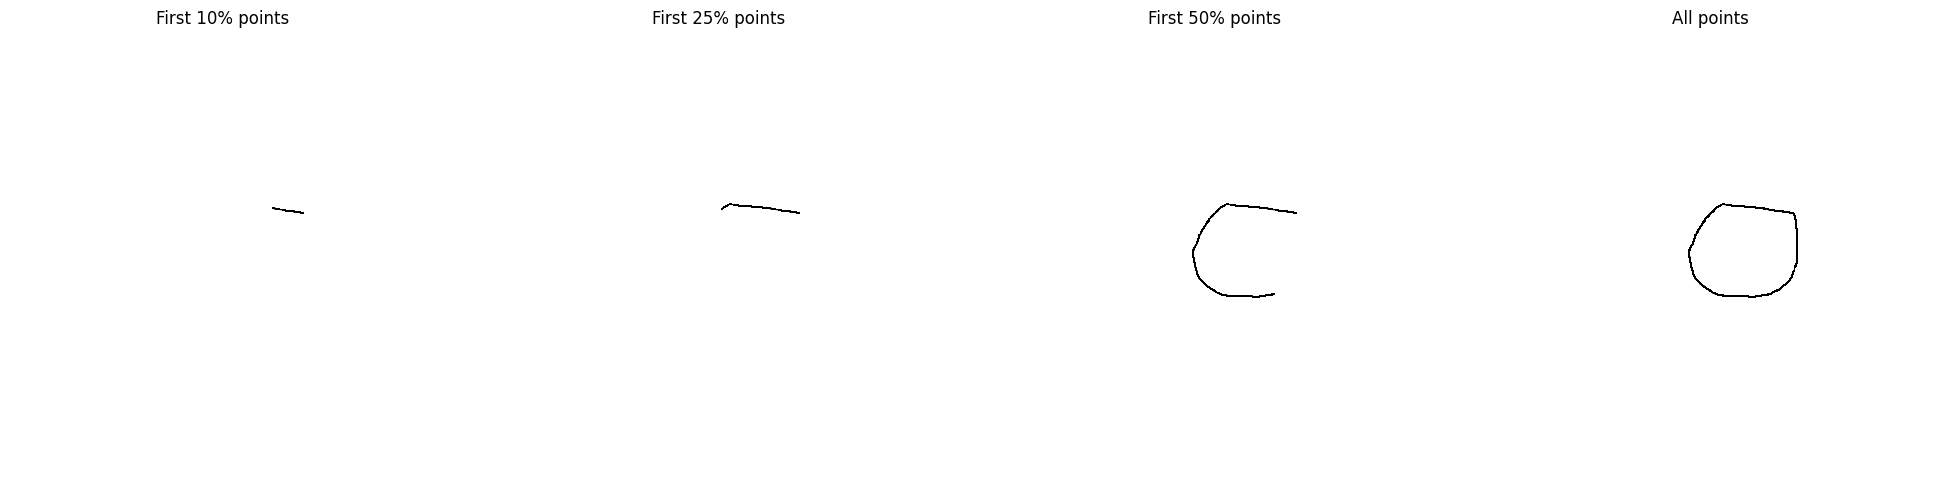

In [12]:
fig, (ax1,ax2,ax3, ax4) = plt.subplots(1, 4, figsize=(20,5))
ax1.axis('off')
ax2.axis('off')
ax3.axis('off')
ax4.axis('off')

centerline_img = np.zeros(map_img.shape)
for x,y in centerline_points[:len(centerline_points)//10]:
	centerline_img[y][x] = 255
ax1.imshow(centerline_img, cmap='Greys', vmax=1, origin='lower')
ax1.set_title("First 10% points")

centerline_img = np.zeros(map_img.shape)
for x,y in centerline_points[:len(centerline_points)//4]:
	centerline_img[y][x] = 255
ax2.imshow(centerline_img, cmap='Greys', vmax=1, origin='lower')
ax2.set_title("First 25% points")

centerline_img = np.zeros(map_img.shape)
for x,y in centerline_points[:int(len(centerline_points)/1.4)]:
	centerline_img[y][x] = 255
ax3.imshow(centerline_img, cmap='Greys', vmax=1, origin='lower')
ax3.set_title("First 50% points")

centerline_img = np.zeros(map_img.shape)
for x,y in centerline_points:
	centerline_img[y][x] = 1000
ax4.imshow(centerline_img, cmap='Greys', vmax=1, origin='lower')
ax4.set_title("All points")
fig.tight_layout()

# Conversion
Convert into Pandas, and go from pixels to meters, and then shift by the origin.

In [13]:
track_widths

[array([41.10960958, 41.10960958]),
 array([40.80441153, 40.80441153]),
 array([40.52159918, 40.52159918]),
 array([40.26164428, 40.26164428]),
 array([39.05124838, 39.05124838]),
 array([38.83297568, 38.83297568]),
 array([38.60051813, 38.60051813]),
 array([38.32753579, 38.32753579]),
 array([38.07886553, 38.07886553]),
 array([36.87817783, 36.87817783]),
 array([36.67424164, 36.67424164]),
 array([36.49657518, 36.49657518]),
 array([36.34556369, 36.34556369]),
 array([36.22154055, 36.22154055]),
 array([36.12478374, 36.12478374]),
 array([36.05551275, 36.05551275]),
 array([35.0142828, 35.0142828]),
 array([35., 35.]),
 array([35., 35.]),
 array([35., 35.]),
 array([35., 35.]),
 array([35., 35.]),
 array([35., 35.]),
 array([35., 35.]),
 array([34., 34.]),
 array([34., 34.]),
 array([34., 34.]),
 array([34., 34.]),
 array([34., 34.]),
 array([34., 34.]),
 array([34., 34.]),
 array([34., 34.]),
 array([33., 33.]),
 array([33., 33.]),
 array([33., 33.]),
 array([33., 33.]),
 array([33

In [14]:
# ─── Savitzky-Golay smoothing + closure fix ───────────────────────────────
# Smooths the raw MST centerline so that:
#   1. Max curvature stays within the vehicle curvature limit
#   2. The closed-loop spline in prep_track.py never has crossed normals
#   3. The closure gap is near-zero (< 0.01m)
from scipy.signal import savgol_filter as _sg

def smooth_centerline(xs, ys, wrs, wls, window=31, poly=3, taper_pts=10, wrap=50):
    n = len(xs)
    # Wrap arrays for periodic boundary treatment
    _wrap = lambda a: np.concatenate([a[-wrap:], a, a[:wrap]])
    xs_s = _sg(_wrap(xs), window, poly)[wrap:wrap+n]
    ys_s = _sg(_wrap(ys), window, poly)[wrap:wrap+n]
    wrs_s = _sg(_wrap(wrs), window, poly)[wrap:wrap+n]
    wls_s = _sg(_wrap(wls), window, poly)[wrap:wrap+n]
    # Taper last `taper_pts` to enforce closure (gap -> ~0)
    blend = np.linspace(0, 1, taper_pts+2)[1:-1]
    for i, b in enumerate(blend):
        idx = n - taper_pts + i
        xs_s[idx] = xs_s[idx]*(1-b) + xs_s[0]*b
        ys_s[idx] = ys_s[idx]*(1-b) + ys_s[0]*b
    return xs_s, ys_s, wrs_s, wls_s

# Extract raw arrays from centerline_points / track_widths
_pts = np.array(centerline_points)
_wid = np.array(track_widths)
raw_x = _pts[:, 0].astype(float)
raw_y = _pts[:, 1].astype(float)
raw_wr = _wid[:, 0].astype(float)
raw_wl = _wid[:, 1].astype(float)

# Determine a safe window size (must be odd, < len)
_n = len(raw_x)
_win = min(31, _n-1 if (_n-1) % 2 == 1 else _n-2)
if _win < 5: _win = 5

raw_x, raw_y, raw_wr, raw_wl = smooth_centerline(
    raw_x, raw_y, raw_wr, raw_wl, window=_win)

# Rebuild centerline_points and track_widths
centerline_points = [np.array([raw_x[i], raw_y[i]]) for i in range(_n)]
track_widths = [np.array([raw_wr[i], raw_wl[i]]) for i in range(_n)]

# Diagnostics
_dx = np.gradient(raw_x); _dy = np.gradient(raw_y)
_ddx = np.gradient(_dx); _ddy = np.gradient(_dy)
_k = np.abs(_dx*_ddy - _dy*_ddx) / (_dx**2 + _dy**2)**1.5
print(f'After SG smoothing: max curvature = {np.max(_k):.3f} rad/m')
print(f'Closure gap: {np.hypot(raw_x[-1]-raw_x[0], raw_y[-1]-raw_y[0]):.4f}m')
print(f'Min total width: {(raw_wr+raw_wl).min():.4f}m')


After SG smoothing: max curvature = 0.179 rad/m
Closure gap: 0.0849m
Min total width: 63.2269m


In [15]:
track_widths_np = np.array(track_widths)
waypoints = np.array(centerline_points)
print(f"Track widths shape: {track_widths_np.shape}, waypoints shape: {waypoints.shape}")

Track widths shape: (556, 2), waypoints shape: (556, 2)


In [16]:
# Merge track with waypoints
data = np.concatenate((waypoints, track_widths_np), axis=1)
data.shape

(556, 4)

In [17]:
# Load map YAML for resolution and origin
with open(map_yaml_path, 'r') as yaml_stream:
    try:
        map_metadata = yaml.safe_load(yaml_stream)
        map_resolution = map_metadata['resolution']
        origin = map_metadata['origin']
    except yaml.YAMLError as ex:
        raise RuntimeError(f"Failed to parse map YAML: {ex}")

orig_x = origin[0]
orig_y = origin[1]
orig_s = np.sin(origin[2])
orig_c = np.cos(origin[2])

# IMPORTANT: use .copy() to avoid mutating 'data' on re-runs
transformed_data = data.copy().astype(np.float64)

# Convert pixel coordinates → meters, then shift by map origin
transformed_data[:, :2] *= map_resolution
transformed_data[:, :2] += np.array([orig_x, orig_y])

# Convert track widths from pixels → meters, then apply safety margin
transformed_data[:, 2:] *= map_resolution
transformed_data[:, 2:] -= TRACK_WIDTH_MARGIN

# Clamp track widths to a minimum of 0 (safety: never negative width)
transformed_data[:, 2:] = np.clip(transformed_data[:, 2:], 0.01, None)

print(f"Map resolution : {map_resolution} m/px")
print(f"Map origin     : ({orig_x:.3f}, {orig_y:.3f})")
print(f"Track width    : min={transformed_data[:, 2].min():.2f}m, max={transformed_data[:, 2].max():.2f}m")
print(f"Waypoints      : {len(transformed_data)}")


Map resolution : 0.012 m/px
Map origin     : (-4.470, -4.140)
Track width    : min=0.38m, max=0.61m
Waypoints      : 556


In [18]:
# Uncomment this if you get the following error: raise IOError("At least two spline normals are crossed, check input or increase smoothing factor!")
transformed_data = transformed_data[::8]

In [19]:
with open(f"inputs/tracks/{MAP_NAME}.csv", 'wb') as fh:
    np.savetxt(fh, transformed_data, fmt='%0.4f', delimiter=',', header='x_m,y_m,w_tr_right_m,w_tr_left_m')

Next up, check out `sanity_check.ipynb` to make sure that the centerline generated lines up with the map.